In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/twitter-sentiment-dataset/Twitter_Data.csv


In [2]:
# Imported all libraries and loaded the csv file
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data_file = pd.read_csv("/kaggle/input/twitter-sentiment-dataset/Twitter_Data.csv")
data_file.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [3]:
data_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [4]:
# Returning the frequency of each value in the "category" column
category_counts = data_file["category"].value_counts()
print(category_counts)

category
 1.0    72250
 0.0    55213
-1.0    35510
Name: count, dtype: int64


In [5]:
# Analyzing the text data to determine the emotional tone
emotion_heading = pd.get_dummies(data_file["category"])
emotion_heading.columns = ["positive", "neutral", "negative"]
print(emotion_heading.head())

   positive  neutral  negative
0      True    False     False
1     False     True     False
2     False    False      True
3     False    False      True
4     False    False      True


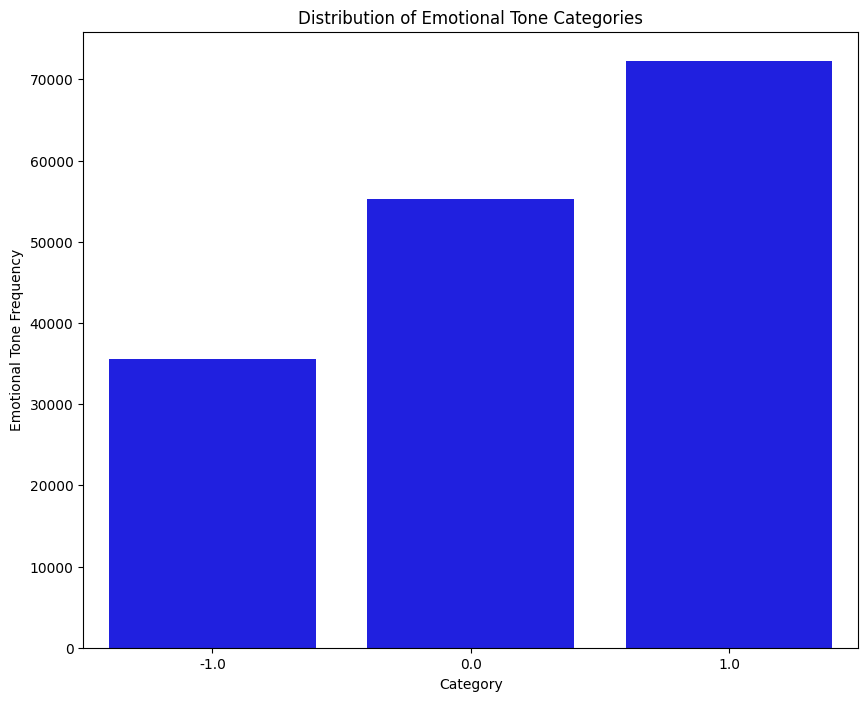

In [6]:
# Displaying the bar graph which shows the distribution of categories
category = data_file['category'].value_counts()
emotional_tone_freq = category.values

plt.figure(figsize = (10, 8))
sns.barplot(x = category.index, y = emotional_tone_freq, color = 'blue')
plt.title('Distribution of Emotional Tone Categories')
plt.xlabel('Category')
plt.ylabel('Emotional Tone Frequency')
plt.show()

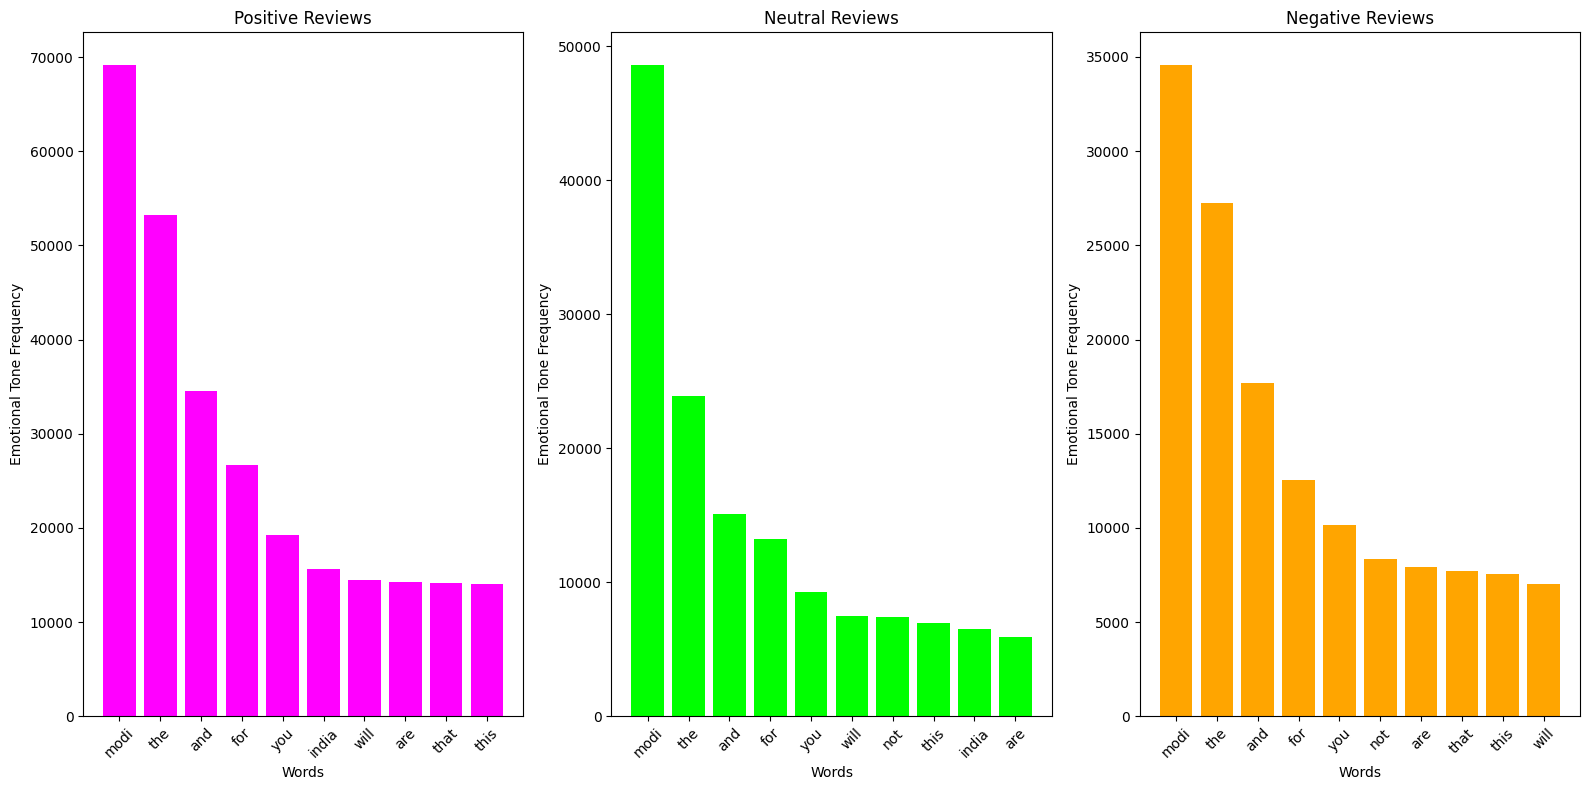

In [7]:
import matplotlib.pyplot as plt
from collections import Counter

# Filter out NaN values from 'clean_text' column
positive_words = ' '.join(data_file[data_file['category'] == 1.0]['clean_text'].dropna())
neutral_words = ' '.join(data_file[data_file['category'] == 0.0]['clean_text'].dropna())
negative_words = ' '.join(data_file[data_file['category'] == -1.0]['clean_text'].dropna())

positive_words_count = Counter(positive_words.split())
neutral_words_count = Counter(neutral_words.split())
negative_words_count = Counter(negative_words.split())

# Displaying the bar graph for each emotional tone category frequency
plt.figure(figsize=(16, 8))

plt.subplot(1, 3, 1)
plt.bar(*zip(*positive_words_count.most_common(10)), width=0.8, color='magenta')
plt.title('Positive Reviews')
plt.xlabel('Words')
plt.ylabel('Emotional Tone Frequency')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
plt.bar(*zip(*neutral_words_count.most_common(10)), width=0.8, color='lime')
plt.title('Neutral Reviews')
plt.xlabel('Words')
plt.ylabel('Emotional Tone Frequency')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
plt.bar(*zip(*negative_words_count.most_common(10)), width=0.8, color='#FFA500')
plt.title('Negative Reviews')
plt.xlabel('Words')
plt.ylabel('Emotional Tone Frequency')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



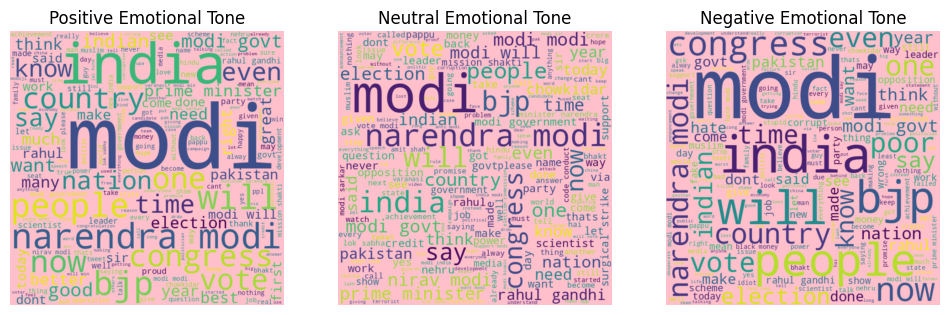

In [8]:
# Generating word clouds for each emotional tone category
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = data_file[data_file['category'] == 1.0]['clean_text'].str.cat(sep=" ")
neutral_text = data_file[data_file['category'] == 0.0]['clean_text'].str.cat(sep=" ")
negative_text = data_file[data_file['category'] == -1.0]['clean_text'].str.cat(sep=" ")


positive_wc = WordCloud(width=600, height=600, min_font_size=10, background_color='pink').generate(positive_text)
neutral_wc = WordCloud(width=600, height=600, min_font_size=10, background_color='pink').generate(neutral_text)
negative_wc = WordCloud(width=600, height=600, min_font_size=10, background_color='pink').generate(negative_text)

# Plot the word clouds
plt.figure(figsize=(12, 12))

plt.subplot(1, 3, 1)
plt.title('Positive Emotional Tone')
plt.imshow(positive_wc, interpolation='bilinear')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Neutral Emotional Tone')
plt.imshow(neutral_wc, interpolation='bilinear')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Negative Emotional Tone')
plt.imshow(negative_wc, interpolation='bilinear')
plt.axis('off')

plt.show()


In [9]:
# Implementation models for sentiment classification
from sklearn.preprocessing import LabelEncoder as LE
from sklearn.model_selection import train_test_split as tts
from sklearn.feature_extraction.text import TfidfVectorizer as TFIDFV
from sklearn.naive_bayes import MultinomialNB as MNB
from sklearn.pipeline import Pipeline as P
from sklearn.metrics import confusion_matrix as CM, accuracy_score as AS


X = data_file['clean_text'].values.astype('U')
y = data_file['category'].values.astype('U')
X_train, X_test, y_train, y_test = tts(X, y, test_size=0.3, stratify=y, random_state=42)

pipeline = P([
    ('tfidf_vectorizer', TFIDFV(lowercase=True, stop_words='english', analyzer='word')), 
    ('naive_bayes', MNB())
])

label_encoder = LE()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

conf_matrix = CM(y_test, y_pred)
print(conf_matrix)

accuracy = AS(y_test, y_pred)
print("Accuracy:", accuracy)


trained_classifier = pipeline.named_steps['naive_bayes']
print(trained_classifier)



[[ 1400   455  8798     0]
 [   46  5518 11000     0]
 [   68   541 21066     0]
 [    0     1     1     0]]
Accuracy: 0.5723401644373542
MultinomialNB()
